# Notebook 02 — Building and Applying Connectivity Masks

**WiringMatters / Stage 1**

This notebook shows how the C. elegans adjacency matrix is transformed into a connectivity mask and applied to a neural network. It covers the three experimental conditions defined in the whitepaper:

1. **Dense baseline** — fully connected (standard MLP)
2. **Uniform sparse baseline** — randomly sparse, same density as the bio mask
3. **Bio-topological** — masked by the real C. elegans connectome

The key question: *what does a mask do to a network, mechanistically?*

---

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import wiringmatters as wm

torch.manual_seed(42)
np.random.seed(42)
print('Seeds fixed: torch=42, numpy=42')

Seeds fixed: torch=42, numpy=42


## 1. From connectome to mask

### Why 448 nodes, not 302?

The canonical figure "302 neurons" refers exclusively to the **somatic nervous system** of *C. elegans* — the number always cited in textbooks and papers, and constant across every individual of the species.

The file we use (`herm_full_edgelist.csv` from OpenWorm) represents the **complete hermaphrodite connectome**, which includes:

| Cell population | Count |
|---|---|
| Somatic neurons (the canonical 302) | 302 |
| Pharyngeal neurons (autonomous gut nervous system) | 20 |
| Muscle cells & other non-neuronal cells that receive synapses | ~126 |
| **Total unique nodes in the chemical synapse edge list** | **448** |

Working with all 448 nodes gives a richer topology than using only the 302 somatic neurons. This choice should be stated explicitly in the Methods section of any paper using WiringMatters.

### Scaling strategy

Our hidden layers have 256 units. We scale the 448×448 adjacency matrix to a 256×256 mask using:
- `target < connectome size (448)`: crop the top-left submatrix
- `target > connectome size (448)`: tile the adjacency with wrap-around

In [2]:
# Load connectome
G, adjacency = wm.load_celegans(synapse_type='chemical', as_matrix=True)
print(f'Connectome adjacency: {adjacency.shape}')

# Build masks for hidden_size=256
HIDDEN_SIZE = 256

bio_m     = wm.bio_mask(adjacency, target_shape=(HIDDEN_SIZE, HIDDEN_SIZE))
density   = wm.mask_density(bio_m)          # returns float directly — no .item() needed
uniform_m = wm.uniform_sparse_mask(target_shape=(HIDDEN_SIZE, HIDDEN_SIZE), density=density)
dense_m   = wm.dense_mask(target_shape=(HIDDEN_SIZE, HIDDEN_SIZE))

print(f'\nBio mask density:       {density:.4f} ({density*100:.2f}% connections active)')
print(f'Uniform sparse density: {wm.mask_density(uniform_m):.4f}')
print(f'Dense density:          {wm.mask_density(dense_m):.4f}')
print(f'\nAll masks are torch.Tensors with requires_grad=False: {not bio_m.requires_grad}')

Connectome adjacency: (448, 448)

Bio mask density:       0.0472 (4.72% connections active)
Uniform sparse density: 0.0470
Dense density:          1.0000

All masks are torch.Tensors with requires_grad=False: True


## 2. Visualizing the three masks

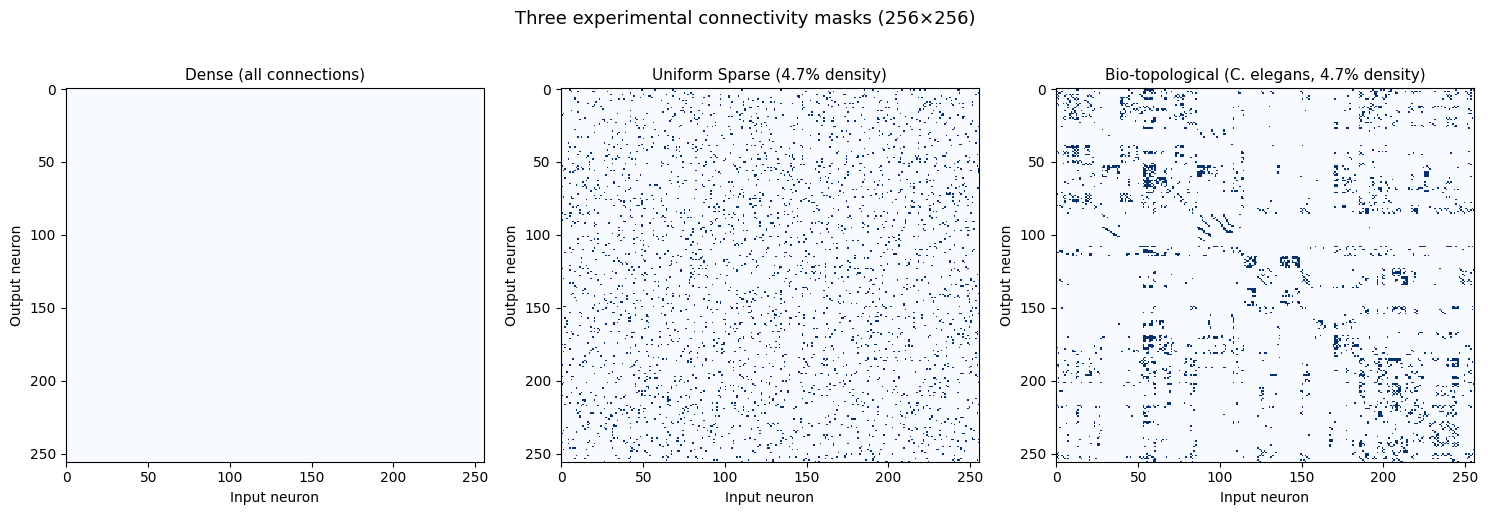

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
masks = [
    (dense_m,    'Dense (all connections)'),
    (uniform_m,  f'Uniform Sparse ({density:.1%} density)'),
    (bio_m,      f'Bio-topological (C. elegans, {density:.1%} density)'),
]

for ax, (mask, title) in zip(axes, masks):
    ax.imshow(mask.numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Input neuron')
    ax.set_ylabel('Output neuron')

plt.suptitle('Three experimental connectivity masks (256×256)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/masks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Building the three model variants

Each model has exactly the same architecture (layer sizes) and the same parameter count for the *active* weights. The only difference is which weights are allowed to be nonzero.

In [ ]:
LAYER_SIZES = [64, HIDDEN_SIZE, HIDDEN_SIZE, 10]  # e.g., digits dataset

# LAYER_SIZES has 3 transitions: 64→256, 256→256, 256→10
# bio_m and uniform_m are 256×256 — they apply only to the square middle layer.
# Non-square layers (64→256 and 256→10) receive None (dense).
torch.manual_seed(42)
model_dense   = wm.BioMLP(LAYER_SIZES, masks=None)

torch.manual_seed(42)
model_uniform = wm.BioMLP(LAYER_SIZES, masks=[None, uniform_m, None])

torch.manual_seed(42)
model_bio     = wm.BioMLP(LAYER_SIZES, masks=[None, bio_m, None])

for name, model in [('Dense', model_dense), ('Uniform Sparse', model_uniform), ('Bio-topological', model_bio)]:
    total = sum(p.numel() for p in model.parameters())
    print(f'{name:<20}: {total:>8,} parameters')

## 4. Mechanics of masking: the forward pass

The masking operates at the weight level: `W_effective = W * M`  
During backpropagation, gradients flow through `W * M`. Since `M` has zero entries, the gradient for masked weights is exactly zero — those weights are never updated.

In [5]:
# Demonstrate gradient zeroing at masked positions
small_mask = torch.tensor([[1., 0.], [0., 1.]])  # identity connectivity
layer = wm.MaskedLinear(in_features=2, out_features=2, mask=small_mask, bias=False)

x = torch.randn(1, 2, requires_grad=True)
out = layer(x).sum()
out.backward()

print('Weight matrix:')
print(layer.weight.data)
print('\nMask:')
print(small_mask)
print('\nGradient of weight (masked positions = 0):')
print(layer.weight.grad)
print('\n→ Positions (0,1) and (1,0) are masked: their gradient is 0.')
print('  These weights are never updated during training. Topology is fixed.')

Weight matrix:
tensor([[ 0.9364,  1.0165],
        [-0.2869,  1.1251]])

Mask:
tensor([[1., 0.],
        [0., 1.]])

Gradient of weight (masked positions = 0):
tensor([[0.2345, 0.0000],
        [0.0000, 0.2303]])

→ Positions (0,1) and (1,0) are masked: their gradient is 0.
  These weights are never updated during training. Topology is fixed.


## 5. Quick sanity check: forward pass shapes

In [6]:
x_test = torch.randn(32, 64)  # batch=32, input_dim=64

for name, model in [('Dense', model_dense), ('Uniform', model_uniform), ('Bio', model_bio)]:
    out = model(x_test)
    print(f'{name:<12}: input {x_test.shape} → output {out.shape}')

print('\nAll models produce identical output shapes. ✓')

NameError: name 'model_uniform' is not defined

## 6. Using BioMLP.from_connectome (the clean API)

For convenience, `BioMLP.from_connectome()` builds any of the three conditions directly from the connectome adjacency matrix.

In [ ]:
for mask_type in ['dense', 'uniform_sparse', 'bio']:
    model = wm.BioMLP.from_connectome(
        adjacency_matrix=adjacency,
        layer_sizes=LAYER_SIZES,
        mask_type=mask_type,
    )
    out = model(x_test)
    print(f'mask_type={mask_type:<15} → output shape {out.shape} ✓')